# Comparing conditions and generating graphs for all conditions

In [13]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, ttest_1samp


In [11]:
#Defining project root
import sys
from pathlib import Path
# Make sure we can import config.py from project root

# One folder up from current notebook location
project_root = Path.cwd().parent.parent.resolve()

# Add subdirectories to path
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'config'))
print(f"Project root: {project_root}")
import config

Project root: /mnt/hdd/anatkorol/Imagination_in_translation


In [ ]:
# unite all dataframes into one
# df = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/3_conditions_with_empty_delay.csv")

df_perc = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/10122025_pilot_2/nlp_analysis/ppt_w_gpt_semantic_tags.csv")
df_im_mem = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/05012026_pilot_2_memory/nlp_analysis/ppt_w_gpt_semantic_tags.csv")
df_delay_mem = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/09022026_pilot_2_delayed_memory/nlp_analysis/ppt_w_gpt_semantic_tags.csv")

In [48]:
#add a condition column to each dataframe
df_perc['condition'] = 'perception'
df_im_mem['condition'] = 'immediate memory'
df_delay_mem['condition'] = 'delayed memory'

In [49]:
# remove the gpt from all, leave a single copy of descriptions
df_perc = df_perc[df_perc["uid"].astype(str).str.strip() != "gpt-5"].copy()
df_im_mem = df_im_mem[df_im_mem["uid"].astype(str).str.strip() != "gpt-5"].copy()


In [50]:
df = pd.concat([df_perc, df_im_mem, df_delay_mem], ignore_index=True)

In [74]:
# turning the category details into actual lists instead of strings
import ast
list_cols = ['objects', 'attr_color', 'attr_shape', 'attr_size', 'attr_material', 'attr_texture', 'attr_pose', 'attr_action', 'attr_state', 'spatial_relations', 'world_knowledge','scene', 'camera_aspects', 'optical_effects', 'subjective_detail'] 

# turning the python strings into real lists
def to_list(x):
    # Already a list
    if isinstance(x, list):
        return x
    # Missing values
    if pd.isna(x):
        return []
    # String that looks like a list
    if isinstance(x, str):
        s = x.strip()
        if s == "" or s.lower() == "null":
            return []
        if s.startswith("[") and s.endswith("]"):
            try:
                v = ast.literal_eval(s)
                return v if isinstance(v, list) else []
            except Exception:
                return []
    # Anything else
    return []

def converted (df):
    # Convert columns to real lists
    for c in list_cols:
        if c in df.columns:
            df[c] = df[c].apply(to_list)
    return df


#apply conversion to each df
df = converted(df)


In [75]:
df.to_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/3_conditions_with_empty_delay.csv", index=False)

# bar plots for relevant counts - 
all conditions, all attempts
gpt as upper limit/another graph

In [107]:
# seperate gpt descriptions into a separate dataframe for now
df_gpt = df[df["uid"].astype(str).str.strip() == "gpt-5"].copy()
df = df[df["uid"].astype(str).str.strip() != "gpt-5"].copy()

In [108]:
df.columns

Index(['uid', 'gt', 'session', 'attempt', 'prompt', 'gen', 'subjective_score',
       'prompt_latency_secs', 'generating_latency_secs', 'rating_latency_secs',
       'ts', 'study_result', 'comp_result', 'verbosity', 'extraction',
       'objects', 'attr_color', 'attr_shape', 'attr_size', 'attr_material',
       'attr_texture', 'attr_pose', 'attr_action', 'attr_state',
       'spatial_relations', 'world_knowledge', 'scene', 'camera_aspects',
       'optical_effects', 'subjective_detail', 'condition',
       'clip_cosine_distance', 'vgg_fc7_distance', 'clip_vis_text_similarity',
       'token_num', 'gt_corrected', 'corrected_gt'],
      dtype='object')

In [112]:
selected_columns = ["objects", "spatial_relations", "attr_color", "attr_size", "attr_texture", "camera_aspects"]

In [113]:
# converting wide to long and adding a count column for the number of items in each category
# required id columns (adjust if your names differ)
id_cols = ["condition", "attempt", "uid", "gt"]

long = df.melt(
    id_vars=id_cols,
    value_vars=selected_columns,
    var_name="category",
    value_name="items"
)

def safe_len(x):
    """Length for list-like; 0 for NaN/None; 1 for scalar non-list values."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return 0
    if isinstance(x, (list, tuple, set, dict)):
        return len(x)
    return 1

long["count"] = long["items"].apply(safe_len)

# Keep category order as selected_columns
long["category"] = pd.Categorical(long["category"], categories=selected_columns, ordered=True)

In [114]:
# #display full column width
# pd.set_option('display.max_colwidth', None)

long.columns

Index(['condition', 'attempt', 'uid', 'gt', 'category', 'items', 'count'], dtype='object')

# simple aggregation without participant variability

In [134]:
#great aggregation but no variance per participant
# # Assuming your dataframe is named 'df'
# # Aggregating across participants (uid) and images (gt)
condition_order = ['perception', 'immediate memory', 'delayed memory']
long['condition'] = pd.Categorical(long['condition'], categories=condition_order, ordered=True)

agg_df = long.groupby(['category', 'condition', 'attempt'], as_index=False)['count'].mean()

# Sort for consistent plotting (Attempt 1, 2, 3)
agg_df = agg_df.sort_values(by=['category', 'condition', 'attempt'])


/tmp/ipykernel_133066/185275190.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = long.groupby(['category', 'condition', 'attempt'], as_index=False)['count'].mean()


In [124]:
agg_df

,category,condition,attempt,count
0,objects,perception,1,7.600000
1,objects,perception,2,8.433333
2,objects,perception,3,9.033333
3,objects,immediate memory,1,6.433333
4,objects,immediate memory,2,6.566667
5,objects,immediate memory,3,6.400000
6,objects,delayed memory,1,3.916667
7,objects,delayed memory,2,5.125000
8,objects,delayed memory,3,5.208333
9,spatial_relations,perception,1,3.400000


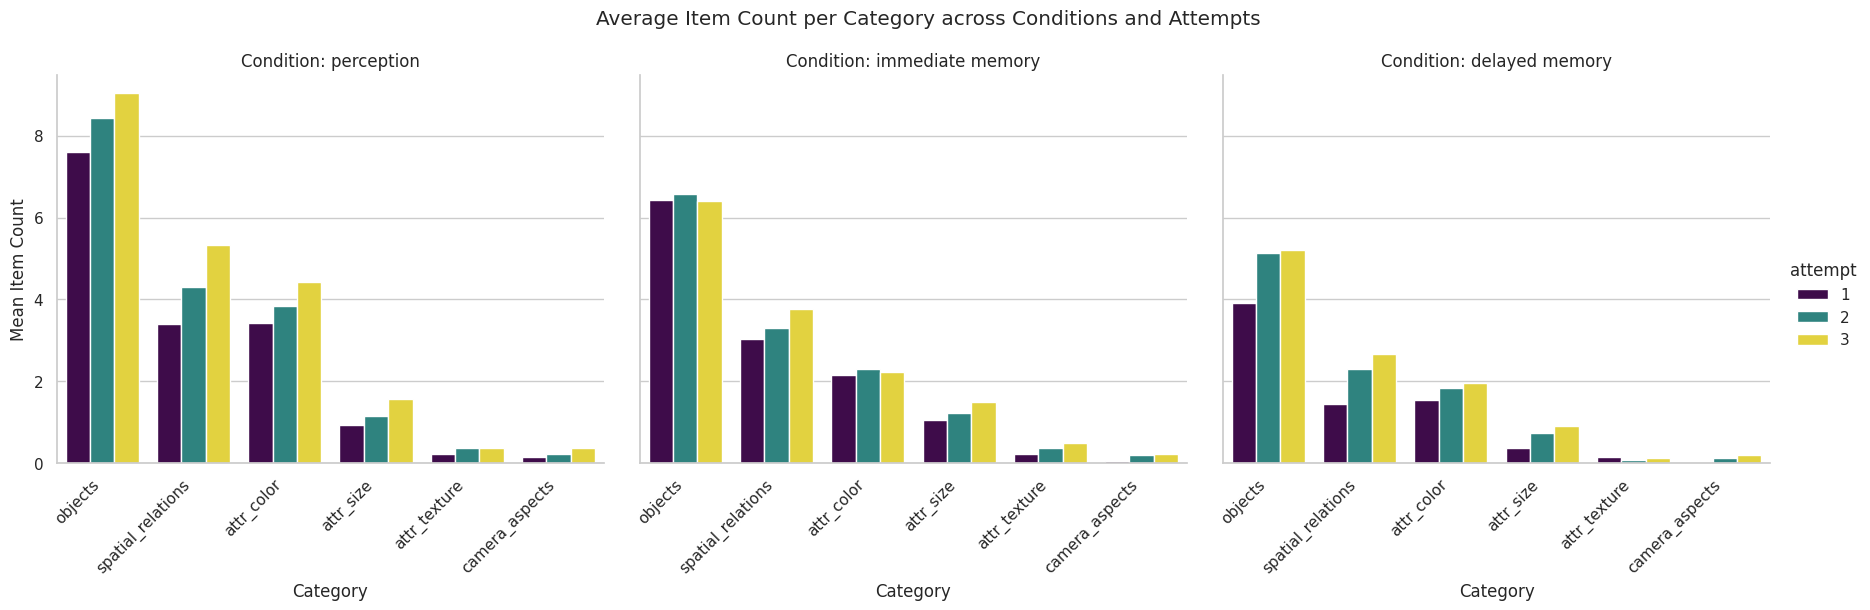

In [126]:
# Setting up the visual style
sns.set_theme(style="whitegrid")

# Creating the faceted bar plot
g = sns.catplot(
    data=agg_df, 
    x='category', 
    y='count', 
    hue='attempt', 
    col='condition', 
    kind='bar',
    palette='viridis',
    height=5, 
    aspect=1.2
)
# Diagonal Labels
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Customizing labels and titles
g.set_axis_labels("Category", "Mean Item Count")
g.set_titles("Condition: {col_name}")
g.fig.suptitle('Average Item Count per Category across Conditions and Attempts', y=1.05)

# plt.savefig('category_analysis_plot.png', bbox_inches='tight')
plt.show()

In [145]:
import plotly.graph_objects as go
import pandas as pd

# 1. Prepare Data
# Sort conditions for the correct order
condition_order = ['perception', 'immediate memory', 'delayed memory']
agg_df['condition'] = pd.Categorical(agg_df['condition'], categories=condition_order, ordered=True)
agg_df = agg_df.sort_values(['category', 'condition', 'attempt'])

# Bar data: Average across the 3 attempts
bar_df = agg_df.groupby(['category', 'condition'], as_index=False)['count'].mean()

# 2. Create Figure
fig = go.Figure()

# 3. Add the Bars (using Viridis-like colors)
viridis_colors = ['#440154', '#21918c', '#fde725'] # Classic Viridis hex codes

for i, cond in enumerate(condition_order):
    cond_data = bar_df[bar_df['condition'] == cond]
    fig.add_trace(go.Bar(
        x=cond_data['category'],
        y=cond_data['count'],
        name=cond,
        marker_color=viridis_colors[i],
        opacity=0.6,
        offsetgroup=i  # This ensures conditions stay side-by-side
    ))

# 4. Add the Dots (Attempt 1, 2, 3)
# We use separate colors for attempts so they are distinct from the bars
attempt_colors = ['#FF4136', '#2ECC40', '#0074D9'] # Red, Green, Blue for clarity

for j, att in enumerate([1, 2, 3]):
    att_data = agg_df[agg_df['attempt'] == att]
    fig.add_trace(go.Scatter(
        x=att_data['category'],
        y=att_data['count'],
        name=f"Attempt {att}",
        mode='markers',
        marker=dict(color=attempt_colors[j], size=10, line=dict(width=1, color='black')),
        offsetgroup=att_data['condition'].map({c: i for i, c in enumerate(condition_order)}),
        alignmentgroup=att_data['condition'].map({c: i for i, c in enumerate(condition_order)})
    ))

# 5. Styling
fig.update_layout(
    barmode='group',
    title="Count by Category and Condition with Attempt Breakdown",
    xaxis_title="Category",
    yaxis_title="Mean Count",
    xaxis_tickangle=-45,
    legend_title="Condition / Attempt",
    template="plotly_white"
)

fig.show()

ModuleNotFoundError: No module named 'plotly'

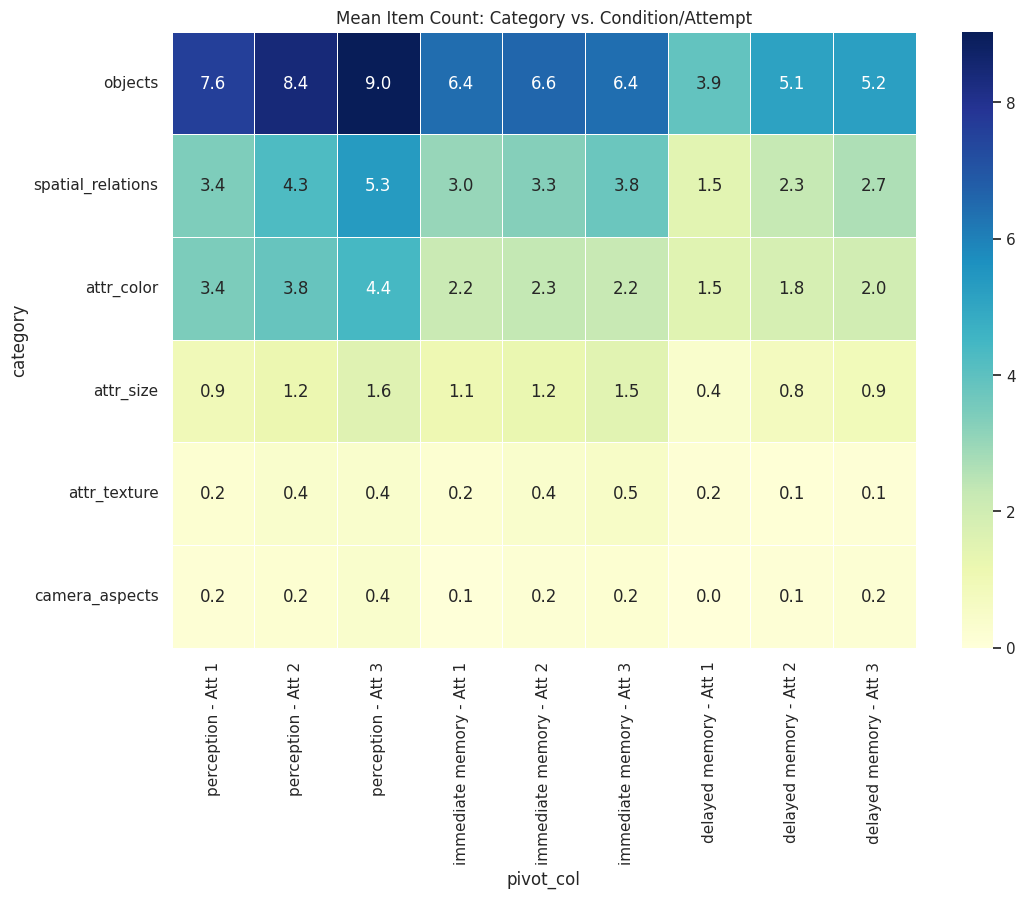

In [130]:
# Create a combined label for the heatmap columns
agg_df['pivot_col'] = agg_df['condition'].astype(str) + " - Att " + agg_df['attempt'].astype(str)

pivot_df = agg_df.pivot(index="category", columns="pivot_col", values="count")

# Reorder columns to follow your condition order
cols = []
for cond in condition_order:
    for att in [1, 2, 3]:
        cols.append(f"{cond} - Att {att}")
pivot_df = pivot_df[cols]

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", fmt=".1f", linewidths=.5)
plt.title("Mean Item Count: Category vs. Condition/Attempt")
plt.show()

# with participant variability

In [121]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Clean the Condition names and set the order
# Ensure your strings match these exactly (check for capitalization/spaces)
condition_order = ['perception', 'immediate memory', 'delayed memory']
long['condition'] = pd.Categorical(long['condition'], categories=condition_order, ordered=True)

# 2. Correct Aggregation
# We include 'condition' in the groupby to keep the participant tied to their group.
# We average the 'count' (averaging across the multiple images 'gt' each person saw).
df_participant = long.groupby(
    ['condition', 'uid', 'category', 'attempt'], 
    as_index=False, 
    observed=True  # IMPORTANT: This prevents pandas from creating empty rows for 
                   # combinations that don't exist (like User A in Condition B)
)['count'].mean()

# 3. Verify the structure
df_participant.sample(5)
# You should see that any given 'uid' is only ever associated with one 'condition'.

,condition,uid,category,attempt,count
276,delayed memory,g9hixqxy1770656910040,attr_color,1,1.2
282,delayed memory,g9hixqxy1770656910040,attr_texture,1,0.2
273,delayed memory,g9hixqxy1770656910040,spatial_relations,1,1.8
43,perception,c2s9h6gg1765201285699,attr_color,2,4.6
94,perception,usj6if3d1765309873263,spatial_relations,2,2.8


/tmp/ipykernel_133066/115268621.py:29: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_133066/115268621.py:29: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_133066/115268621.py:29: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


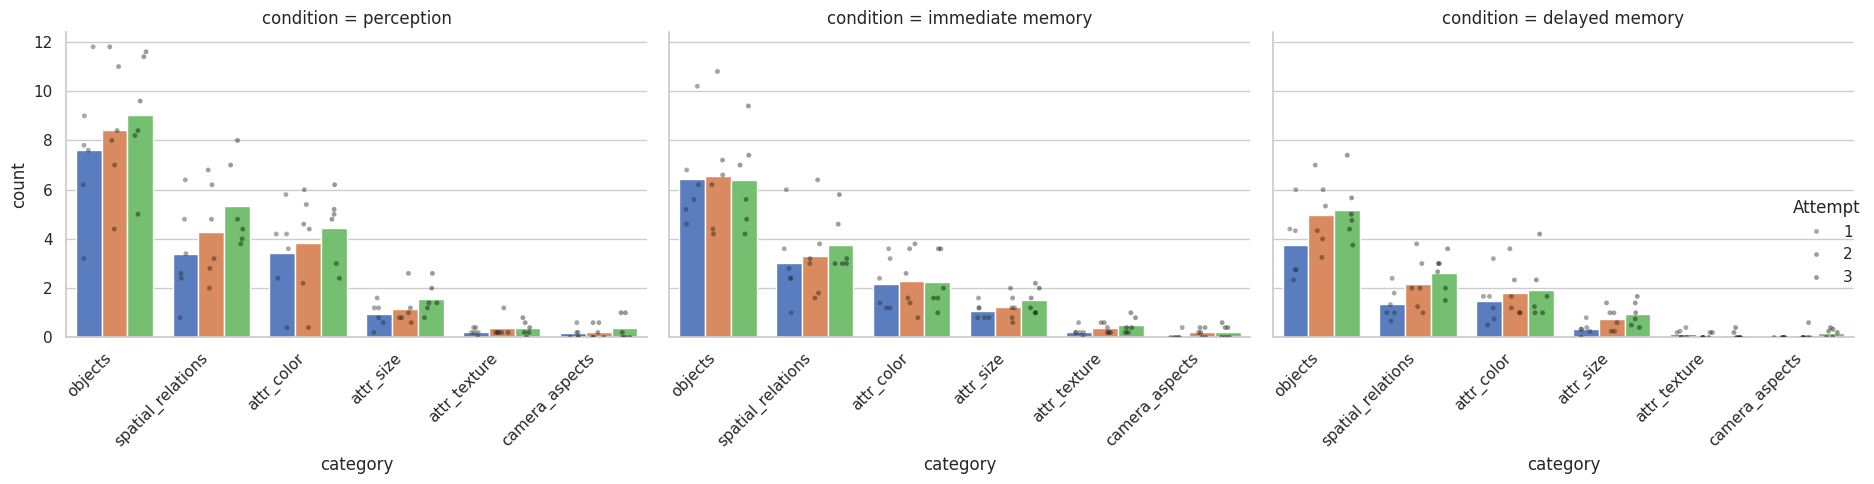

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Choose your colors
bar_palette = "muted"   # "muted", "deep", or "Dark2" are good for darker bars
dot_color = "black"     # Using a single dark color for dots often looks cleaner

sns.set_theme(style="whitegrid")

g = sns.FacetGrid(
    df_participant, 
    col="condition", 
    col_order=['perception', 'immediate memory', 'delayed memory'],
    height=5, 
    aspect=1.2
)

def draw_study_data(data, **kwargs):
    ax = plt.gca()
    
    # DARKER BARS: alpha=1.0 makes them fully opaque
    sns.barplot(
        data=data, x="category", y="count", hue="attempt",
        palette=bar_palette, alpha=1.0, errorbar=None, ax=ax
    )
    
    # CONTRASTING DOTS: Using 'black' or '0.2' (dark gray) 
    # dodge=True keeps them aligned with the specific attempt bar
    sns.stripplot(
        data=data, x="category", y="count", hue="attempt",
        color=dot_color, dodge=True, alpha=0.4, size=3.5, jitter=0.2, ax=ax
    )
    
    if ax.get_legend(): ax.get_legend().remove()

g.map_dataframe(draw_study_data)

# Diagonal Labels
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

g.add_legend(title="Attempt")
plt.tight_layout()
plt.show()